# Predicting Irrigation Need: Stacking Ensemble (HW4)
Lucas Calaff  
04/28/26

**Primary metric: Balanced Accuracy** (macro-averaged recall across High / Low / Medium classes)

## Overview
1. Feature engineering — interactions, transformations, grouping
2. Four meaningfully different base models — HistGBM, LightGBM, Random Forest, XGBoost
3. Feature importance evaluation — built-in importance, permutation importance, SHAP
4. Stacking ensemble — OOF meta-learner + probability averaging

## 1. Imports & Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import shap

np.random.seed(42)

## 2. Data Loading & Exploration

In [6]:
train_df = pd.read_csv('train.csv').drop(columns=['id'])
test_df  = pd.read_csv('test.csv')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
print('\nClass distribution:')
print(train_df['Irrigation_Need'].value_counts(normalize=True).round(4))
train_df.head()

Train shape: (630000, 20)
Test shape:  (270000, 20)

Class distribution:
Irrigation_Need
Low       0.5872
Medium    0.3795
High      0.0333
Name: proportion, dtype: float64


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [7]:
# Quick look at numeric distributions
num_cols = train_df.select_dtypes(include='number').columns.tolist()
train_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00
Field_Area_hectare,630000.0,7.517745,4.218124,0.30,3.8800,7.38,11.14,15.00


## 3. Feature Engineering

Four categories of new features:
- **Log transformations** for right-skewed numerics
- **Ratio / interaction features** capturing domain relationships (e.g., evapotranspiration demand, water stress)
- **Binning / grouping** of continuous variables into meaningful categories
- **Categorical interactions** combining season × crop type and soil × region

In [8]:
def engineer_features(df):
    """Add domain-motivated features to a copy of df."""
    d = df.copy()

    # --- Log Transformations ---
    # Rainfall and field area are right-skewed; log compresses outliers
    d['Log_Rainfall']   = np.log1p(d['Rainfall_mm'])
    d['Log_Field_Area'] = np.log1p(d['Field_Area_hectare'])

    # --- Ratio / Interaction Features ---
    # Evapotranspiration proxy: high temp, low humidity, high sunlight → more water loss
    d['ET_Proxy'] = d['Temperature_C'] * (1 - d['Humidity'] / 100) * d['Sunlight_Hours']

    # Soil water stress: ratio of stored moisture to atmospheric humidity demand
    d['Soil_Water_Stress'] = d['Soil_Moisture'] / (d['Humidity'] + 1)

    # Rainfall efficiency per unit area (how much rain per hectare)
    d['Rain_Per_Hectare'] = d['Rainfall_mm'] / (d['Field_Area_hectare'] + 0.01)

    # Salinity-to-organic ratio: high EC with low OC can reduce crop water uptake
    d['EC_OC_Ratio'] = d['Electrical_Conductivity'] / (d['Organic_Carbon'] + 0.01)

    # Wind chill effect on evaporation demand
    d['Wind_Evap_Index'] = d['Wind_Speed_kmh'] * d['Temperature_C'] / (d['Humidity'] + 1)

    # Previous irrigation relative to rainfall: captures irrigation vs rain dependency
    d['Irrig_Rain_Ratio'] = d['Previous_Irrigation_mm'] / (d['Rainfall_mm'] + 1)

    # pH deviation from neutral (7.0): plants stressed at extremes
    d['pH_Deviation'] = abs(d['Soil_pH'] - 7.0)

    # --- Binning / Grouping ---
    # Soil pH into agronomic categories
    d['pH_Category'] = pd.cut(
        d['Soil_pH'],
        bins=[0, 5.5, 7.0, 8.0, 14],
        labels=['Acidic', 'Slightly_Acidic', 'Neutral', 'Alkaline']
    ).astype(str)

    # Temperature zone bins
    d['Temp_Zone'] = pd.cut(
        d['Temperature_C'],
        bins=[-np.inf, 15, 25, 35, np.inf],
        labels=['Cool', 'Moderate', 'Warm', 'Hot']
    ).astype(str)

    # Humidity level grouping
    d['Humidity_Level'] = pd.cut(
        d['Humidity'],
        bins=[0, 40, 60, 80, 100],
        labels=['Low', 'Moderate', 'High', 'Very_High']
    ).astype(str)

    # --- Categorical Interactions ---
    # Season × Crop Type: different crops have different water needs per season
    d['Season_Crop'] = d['Season'].astype(str) + '_' + d['Crop_Type'].astype(str)

    # Soil Type × Region: soil-region combo affects irrigation need
    d['Soil_Region'] = d['Soil_Type'].astype(str) + '_' + d['Region'].astype(str)

    # Growth Stage × Irrigation Type: current stage combined with current method
    d['Stage_IrrigType'] = d['Crop_Growth_Stage'].astype(str) + '_' + d['Irrigation_Type'].astype(str)

    return d


train_fe = engineer_features(train_df)
test_fe  = engineer_features(test_df.drop(columns=['id']))

print('Features before engineering:', train_df.shape[1] - 1)  # exclude target
print('Features after engineering: ', train_fe.shape[1] - 1)
print('\nNew feature columns:')
new_cols = [c for c in train_fe.columns if c not in train_df.columns]
print(new_cols)

Features before engineering: 19
Features after engineering:  34

New feature columns:
['Log_Rainfall', 'Log_Field_Area', 'ET_Proxy', 'Soil_Water_Stress', 'Rain_Per_Hectare', 'EC_OC_Ratio', 'Wind_Evap_Index', 'Irrig_Rain_Ratio', 'pH_Deviation', 'pH_Category', 'Temp_Zone', 'Humidity_Level', 'Season_Crop', 'Soil_Region', 'Stage_IrrigType']


## 4. Preprocessing

Encode all categorical columns with `pd.get_dummies` then split. Target is label-encoded.

In [9]:
X_raw = train_fe.drop(columns=['Irrigation_Need'])
y_raw = train_fe['Irrigation_Need']

# Label-encode the target
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
print('Classes:', le.classes_)

# Train / validation split (stratified to preserve class ratios)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# One-hot encode all categoricals (drop_first avoids perfect multicollinearity)
X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_val   = pd.get_dummies(X_val_raw,   drop_first=True)
X_val   = X_val.reindex(columns=X_train.columns, fill_value=0)

# Test set (no target)
X_test_proc = pd.get_dummies(test_fe, drop_first=True)
X_test_proc = X_test_proc.reindex(columns=X_train.columns, fill_value=0)

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test_proc.shape}')

Classes: ['High' 'Low' 'Medium']
X_train shape: (504000, 104)
X_val shape:   (126000, 104)
X_test shape:  (270000, 104)


## 5. Base Model 1 — HistGradientBoosting

Fast native-NaN support; sequential tree boosting with histogram binning. Tuned via GridSearch on three key hyperparameters.

In [10]:
hgbm_base = HistGradientBoostingClassifier(random_state=42)
hgbm_base.fit(X_train, y_train)
hgbm_base_pred = hgbm_base.predict(X_val)
print('HGBM Base Balanced Accuracy:', balanced_accuracy_score(y_val, hgbm_base_pred))

HGBM Base Balanced Accuracy: 0.9626809707796845


In [11]:
# Tune learning rate
hgbm_lr_grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid={'learning_rate': [0.05, 0.1, 0.2, 0.3]},
    cv=3, scoring='balanced_accuracy', n_jobs=-1
)
hgbm_lr_grid.fit(X_train, y_train)
print('Best LR:', hgbm_lr_grid.best_params_, '| CV BA:', round(hgbm_lr_grid.best_score_, 4))

Best LR: {'learning_rate': 0.05} | CV BA: 0.9602


In [12]:
# Tune max_leaf_nodes
hgbm_leaf_grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid={'max_leaf_nodes': [15, 31, 63, 127]},
    cv=3, scoring='balanced_accuracy', n_jobs=-1
)
hgbm_leaf_grid.fit(X_train, y_train)
print('Best max_leaf_nodes:', hgbm_leaf_grid.best_params_, '| CV BA:', round(hgbm_leaf_grid.best_score_, 4))

Best max_leaf_nodes: {'max_leaf_nodes': 31} | CV BA: 0.9598


In [13]:
# Build tuned HGBM
hgbm_tuned = HistGradientBoostingClassifier(
    learning_rate=hgbm_lr_grid.best_params_['learning_rate'],
    max_leaf_nodes=hgbm_leaf_grid.best_params_['max_leaf_nodes'],
    random_state=42
)
hgbm_tuned.fit(X_train, y_train)
hgbm_pred = hgbm_tuned.predict(X_val)

hgbm_ba = balanced_accuracy_score(y_val, hgbm_pred)
print('Tuned HGBM Balanced Accuracy:', round(hgbm_ba, 4))
print(classification_report(y_val, hgbm_pred, target_names=le.classes_))

Tuned HGBM Balanced Accuracy: 0.9629
              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.98      0.98      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



## 6. Base Model 2 — LightGBM

Leaf-wise growth strategy (vs. level-wise in HGBM); much faster and often higher accuracy. Tuned on n_estimators, learning_rate, and num_leaves.

In [14]:
lgbm_base = LGBMClassifier(random_state=42, verbose=-1)
lgbm_base.fit(X_train, y_train)
lgbm_base_pred = lgbm_base.predict(X_val)
print('LGBM Base Balanced Accuracy:', balanced_accuracy_score(y_val, lgbm_base_pred))

LGBM Base Balanced Accuracy: 0.9637996033969358


In [15]:
# Tune num_leaves and n_estimators jointly via RandomizedSearch for speed
lgbm_param_dist = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves':    [31, 63, 127, 255]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=12, cv=3, scoring='balanced_accuracy',
    random_state=42, n_jobs=-1
)
lgbm_search.fit(X_train, y_train)
print('Best params:', lgbm_search.best_params_)
print('Best CV BA:', round(lgbm_search.best_score_, 4))

Best params: {'num_leaves': 63, 'n_estimators': 200, 'learning_rate': 0.05}
Best CV BA: 0.9607


In [16]:
lgbm_tuned = LGBMClassifier(**lgbm_search.best_params_, random_state=42, verbose=-1)
lgbm_tuned.fit(X_train, y_train)
lgbm_pred = lgbm_tuned.predict(X_val)

lgbm_ba = balanced_accuracy_score(y_val, lgbm_pred)
print('Tuned LGBM Balanced Accuracy:', round(lgbm_ba, 4))
print(classification_report(y_val, lgbm_pred, target_names=le.classes_))

Tuned LGBM Balanced Accuracy: 0.9642
              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



## 7. Base Model 3 — Random Forest

Bagging + feature randomness (vs. sequential boosting in models 1 and 2). Uses `class_weight='balanced'` to address the class imbalance in the 'High' class (~3.4% of samples).

In [17]:
rf_base = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
rf_base.fit(X_train, y_train)
rf_base_pred = rf_base.predict(X_val)
print('RF Base Balanced Accuracy:', balanced_accuracy_score(y_val, rf_base_pred))

RF Base Balanced Accuracy: 0.9613632132165685


In [18]:
rf_param_dist = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 20, 30],
    'min_samples_leaf':  [1, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10, cv=3, scoring='balanced_accuracy',
    random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print('Best params:', rf_search.best_params_)
print('Best CV BA:', round(rf_search.best_score_, 4))

Best params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 20}
Best CV BA: 0.9647


In [19]:
rf_tuned = RandomForestClassifier(
    **rf_search.best_params_,
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf_tuned.fit(X_train, y_train)
rf_pred = rf_tuned.predict(X_val)

rf_ba = balanced_accuracy_score(y_val, rf_pred)
print('Tuned RF Balanced Accuracy:', round(rf_ba, 4))
print(classification_report(y_val, rf_pred, target_names=le.classes_))

Tuned RF Balanced Accuracy: 0.9674
              precision    recall  f1-score   support

        High       0.91      0.94      0.93      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.96      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



## 8. Base Model 4 — XGBoost

Different regularization structure than HGBM/LGBM (L1 + L2 penalties, shrinkage). Uses `scale_pos_weight` per class via sample weights to handle the imbalanced High class.

In [20]:
from sklearn.utils.class_weight import compute_sample_weight

# Compute per-sample class weights based on inverse frequency
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_base = XGBClassifier(
    eval_metric='mlogloss', use_label_encoder=False,
    tree_method='hist', random_state=42, n_jobs=-1
)
xgb_base.fit(X_train, y_train, sample_weight=sample_weights_train)
xgb_base_pred = xgb_base.predict(X_val)
print('XGB Base Balanced Accuracy:', balanced_accuracy_score(y_val, xgb_base_pred))

XGB Base Balanced Accuracy: 0.9714749011749072


In [21]:
xgb_param_dist = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [4, 6, 8],
    'subsample':     [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        eval_metric='mlogloss', use_label_encoder=False,
        tree_method='hist', random_state=42, n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=10, cv=3, scoring='balanced_accuracy',
    random_state=42, n_jobs=-1
)
# Pass sample weights via fit_params
xgb_search.fit(X_train, y_train, sample_weight=sample_weights_train)
print('Best params:', xgb_search.best_params_)
print('Best CV BA:', round(xgb_search.best_score_, 4))

Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV BA: 0.9696


In [22]:
xgb_tuned = XGBClassifier(
    **xgb_search.best_params_,
    eval_metric='mlogloss', use_label_encoder=False,
    tree_method='hist', random_state=42, n_jobs=-1
)
xgb_tuned.fit(X_train, y_train, sample_weight=sample_weights_train)
xgb_pred = xgb_tuned.predict(X_val)

xgb_ba = balanced_accuracy_score(y_val, xgb_pred)
print('Tuned XGB Balanced Accuracy:', round(xgb_ba, 4))
print(classification_report(y_val, xgb_pred, target_names=le.classes_))

Tuned XGB Balanced Accuracy: 0.9725
              precision    recall  f1-score   support

        High       0.88      0.95      0.91      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



## 9. Feature Importance Evaluation

### 9a. Built-in Feature Importance (LightGBM)
Fast and model-specific; shows which splits are used most. Biased toward high-cardinality features.

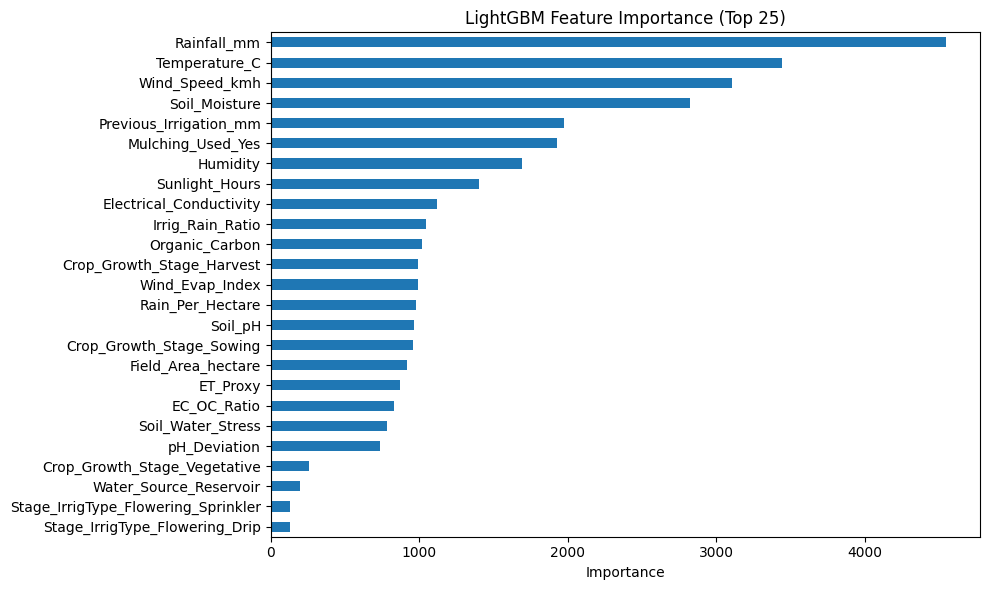

Top 15 features by LGBM importance:
Rainfall_mm                  4550
Temperature_C                3442
Wind_Speed_kmh               3105
Soil_Moisture                2825
Previous_Irrigation_mm       1975
Mulching_Used_Yes            1929
Humidity                     1693
Sunlight_Hours               1401
Electrical_Conductivity      1118
Irrig_Rain_Ratio             1043
Organic_Carbon               1022
Crop_Growth_Stage_Harvest     994
Wind_Evap_Index               994
Rain_Per_Hectare              979
Soil_pH                       967


In [23]:
lgbm_feat_imp = pd.Series(
    lgbm_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
lgbm_feat_imp.head(25).plot(kind='barh')
plt.title('LightGBM Feature Importance (Top 25)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 15 features by LGBM importance:')
print(lgbm_feat_imp.head(15).to_string())

### 9b. Permutation Importance (XGBoost)
Model-agnostic; measures actual drop in balanced accuracy when a feature is randomly shuffled. More reliable than built-in importance for identifying features that truly matter at prediction time.

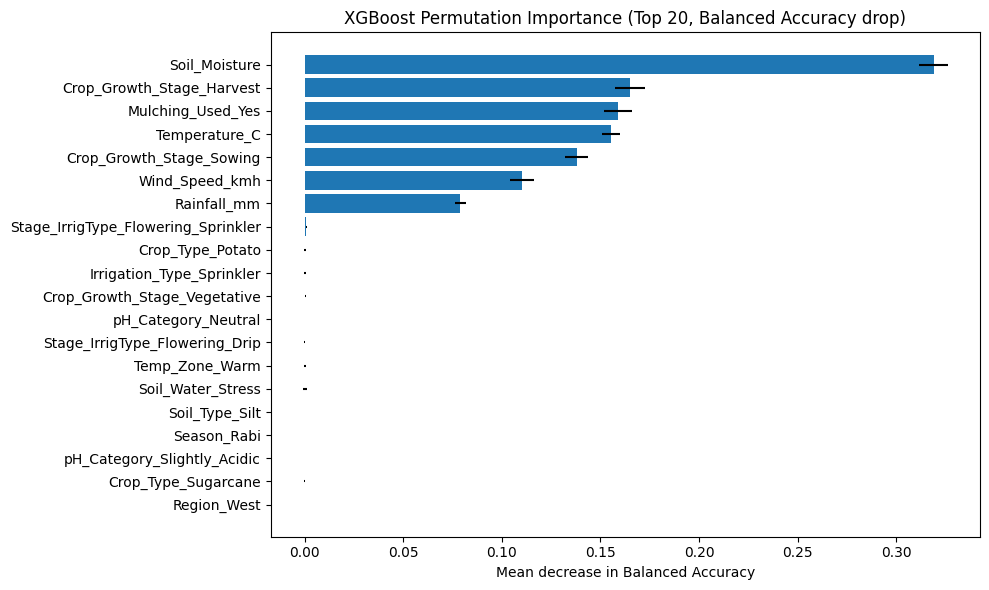


Top 15 features by permutation importance:
                            feature  importance_mean  importance_std
                      Soil_Moisture         0.319007        0.007177
          Crop_Growth_Stage_Harvest         0.164876        0.007706
                  Mulching_Used_Yes         0.159109        0.007060
                      Temperature_C         0.155264        0.004481
           Crop_Growth_Stage_Sowing         0.137970        0.005764
                     Wind_Speed_kmh         0.110370        0.006160
                        Rainfall_mm         0.078891        0.002731
Stage_IrrigType_Flowering_Sprinkler         0.000755        0.000256
                   Crop_Type_Potato         0.000302        0.000447
          Irrigation_Type_Sprinkler         0.000269        0.000460
       Crop_Growth_Stage_Vegetative         0.000227        0.000157
                pH_Category_Neutral         0.000089        0.000120
     Stage_IrrigType_Flowering_Drip         0.000083       

In [24]:
# Use a random sample of val set to keep computation fast
val_sample_idx = np.random.choice(len(X_val), size=min(10000, len(X_val)), replace=False)
X_val_sample = X_val.iloc[val_sample_idx]
y_val_sample = y_val[val_sample_idx]

perm_imp = permutation_importance(
    xgb_tuned, X_val_sample, y_val_sample,
    n_repeats=10, random_state=42,
    scoring='balanced_accuracy'
)

perm_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm_imp.importances_mean,
    'importance_std':  perm_imp.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
top_perm = perm_df.head(20)
plt.barh(top_perm['feature'], top_perm['importance_mean'],
         xerr=top_perm['importance_std'], align='center')
plt.gca().invert_yaxis()
plt.title('XGBoost Permutation Importance (Top 20, Balanced Accuracy drop)')
plt.xlabel('Mean decrease in Balanced Accuracy')
plt.tight_layout()
plt.show()

print('\nTop 15 features by permutation importance:')
print(perm_df.head(15)[['feature', 'importance_mean', 'importance_std']].to_string(index=False))

### 9c. SHAP Analysis (LightGBM)
SHAP values give consistent, game-theoretic attribution of each feature's contribution to each prediction. Unlike importance scores, SHAP shows both magnitude and direction.

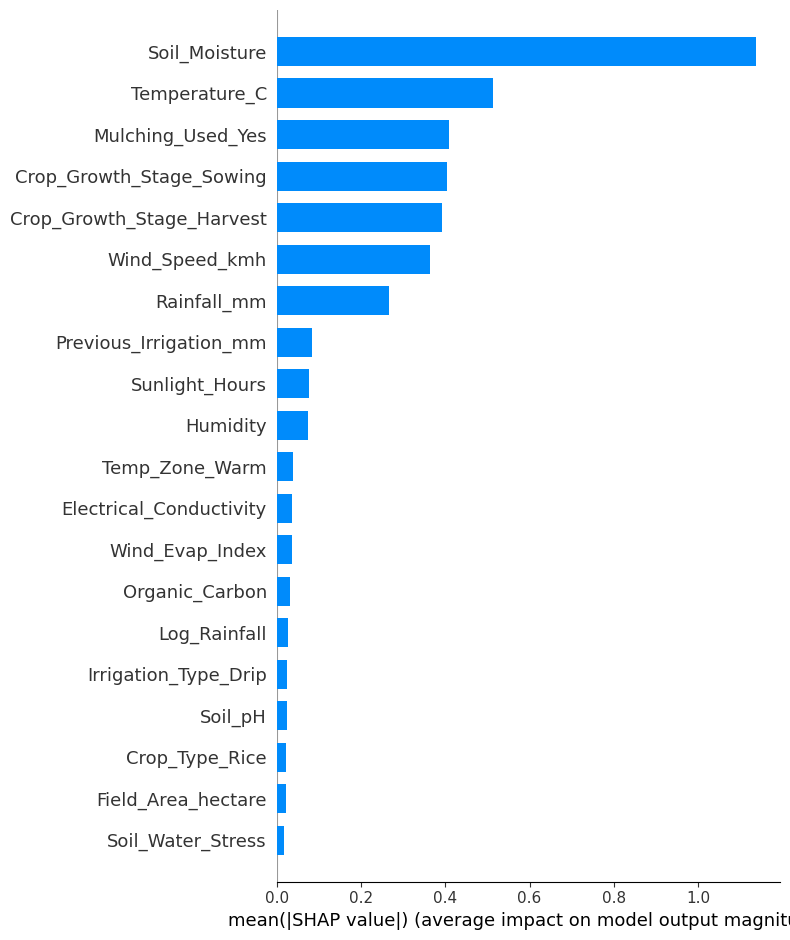

In [25]:
# Sample the validation set for SHAP (TreeExplainer is fast but still benefits from a subset)
shap_sample = X_val.iloc[:3000]

explainer = shap.TreeExplainer(lgbm_tuned)
shap_values = explainer.shap_values(shap_sample)

# Newer SHAP versions return a 3D array (n_samples, n_features, n_classes).
# Older versions return a list of 2D arrays, one per class.
# Normalize to always get a 2D (n_samples, n_features) array for the target class.
class_idx = list(le.classes_).index('High')

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv_high = shap_values[:, :, class_idx]   # new API
else:
    sv_high = shap_values[class_idx]          # old API

shap.summary_plot(
    sv_high,
    shap_sample,
    plot_type='bar',
    max_display=20,
    show=True
)

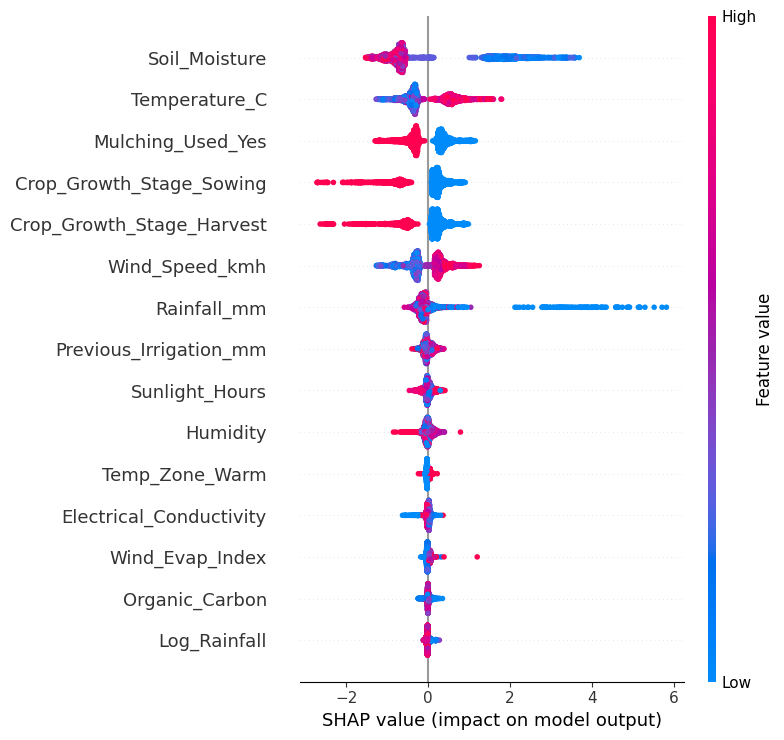

In [26]:
# Beeswarm: shows direction and magnitude per observation
shap.summary_plot(
    sv_high,
    shap_sample,
    max_display=15,
    show=True
)

### 9d. Feature Utility Summary

Compare engineered features vs original features using averaged importance rankings.

In [27]:
# Combine LGBM built-in and XGB permutation importance into a single rank table
lgbm_rank = lgbm_feat_imp.rank(ascending=False).rename('lgbm_rank')
perm_rank  = perm_df.set_index('feature')['importance_mean'].rank(ascending=False).rename('perm_rank')

combined_rank = pd.concat([lgbm_rank, perm_rank], axis=1)
combined_rank['avg_rank'] = combined_rank.mean(axis=1)
combined_rank = combined_rank.sort_values('avg_rank')

# Separate engineered from original
engineered_features = [
    'Log_Rainfall', 'Log_Field_Area', 'ET_Proxy', 'Soil_Water_Stress',
    'Rain_Per_Hectare', 'EC_OC_Ratio', 'Wind_Evap_Index', 'Irrig_Rain_Ratio',
    'pH_Deviation'
]

# Check which engineered features appear in top 30
top30 = combined_rank.head(30)
eng_in_top30 = [f for f in engineered_features if any(f in idx for idx in top30.index)]

print('Engineered features appearing in top-30 combined rank:')
for f in eng_in_top30:
    matching = [idx for idx in top30.index if f in idx]
    for m in matching:
        print(f'  {m}: avg rank = {combined_rank.loc[m, "avg_rank"]:.1f}')

print('\nTop 20 features (averaged importance rank):')
print(combined_rank.head(20)[['lgbm_rank', 'perm_rank', 'avg_rank']].to_string())

Engineered features appearing in top-30 combined rank:
  Soil_Water_Stress: avg rank = 17.5

Top 20 features (averaged importance rank):
                                     lgbm_rank  perm_rank  avg_rank
Soil_Moisture                              4.0        1.0      2.50
Temperature_C                              2.0        4.0      3.00
Rainfall_mm                                1.0        7.0      4.00
Wind_Speed_kmh                             3.0        6.0      4.50
Mulching_Used_Yes                          6.0        3.0      4.50
Crop_Growth_Stage_Harvest                 12.5        2.0      7.25
Crop_Growth_Stage_Sowing                  16.0        5.0     10.50
Stage_IrrigType_Flowering_Sprinkler       24.0        8.0     16.00
Crop_Growth_Stage_Vegetative              22.0       11.0     16.50
Soil_Water_Stress                         20.0       15.0     17.50
Stage_IrrigType_Flowering_Drip            25.0       13.0     19.00
Irrigation_Type_Sprinkler                 29.0 

## 10. Stacking Ensemble — OOF Meta-Learner

**Strategy:** Generate out-of-fold (OOF) probability predictions from all four base models. Stack those as features for a Logistic Regression meta-learner. This avoids data leakage — the meta-model only sees predictions it could not have memorized.

Base models: HGBM, LightGBM, Random Forest, XGBoost  
Meta-model: Logistic Regression (simple, interpretable)

In [28]:
# Combine full training data (train + val) for OOF generation
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = np.concatenate([y_train, y_val])

n_classes = len(le.classes_)
n_full    = len(X_full)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF probability arrays: shape (n_samples, n_classes) per model
oof_hgbm  = np.zeros((n_full, n_classes))
oof_lgbm  = np.zeros((n_full, n_classes))
oof_rf    = np.zeros((n_full, n_classes))
oof_xgb   = np.zeros((n_full, n_classes))

print('Generating OOF predictions (5 folds)...')

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_full, y_full)):
    X_tr, X_vl = X_full.iloc[tr_idx], X_full.iloc[vl_idx]
    y_tr, y_vl = y_full[tr_idx],      y_full[vl_idx]
    sw_tr = compute_sample_weight('balanced', y=y_tr)

    # HGBM
    m_hgbm = HistGradientBoostingClassifier(
        learning_rate=hgbm_lr_grid.best_params_['learning_rate'],
        max_leaf_nodes=hgbm_leaf_grid.best_params_['max_leaf_nodes'],
        random_state=42
    )
    m_hgbm.fit(X_tr, y_tr)
    oof_hgbm[vl_idx] = m_hgbm.predict_proba(X_vl)

    # LGBM
    m_lgbm = LGBMClassifier(**lgbm_search.best_params_, random_state=42, verbose=-1)
    m_lgbm.fit(X_tr, y_tr)
    oof_lgbm[vl_idx] = m_lgbm.predict_proba(X_vl)

    # Random Forest
    m_rf = RandomForestClassifier(
        **rf_search.best_params_,
        class_weight='balanced', n_jobs=-1, random_state=42
    )
    m_rf.fit(X_tr, y_tr)
    oof_rf[vl_idx] = m_rf.predict_proba(X_vl)

    # XGBoost
    m_xgb = XGBClassifier(
        **xgb_search.best_params_,
        eval_metric='mlogloss', use_label_encoder=False,
        tree_method='hist', random_state=42, n_jobs=-1
    )
    m_xgb.fit(X_tr, y_tr, sample_weight=sw_tr)
    oof_xgb[vl_idx] = m_xgb.predict_proba(X_vl)

    fold_preds = np.argmax(
        (oof_hgbm[vl_idx] + oof_lgbm[vl_idx] + oof_rf[vl_idx] + oof_xgb[vl_idx]) / 4,
        axis=1
    )
    print(f'  Fold {fold+1} avg ensemble BA: {balanced_accuracy_score(y_vl, fold_preds):.4f}')

print('OOF generation complete.')

Generating OOF predictions (5 folds)...
  Fold 1 avg ensemble BA: 0.9651
  Fold 2 avg ensemble BA: 0.9656
  Fold 3 avg ensemble BA: 0.9637
  Fold 4 avg ensemble BA: 0.9659
  Fold 5 avg ensemble BA: 0.9653
OOF generation complete.


In [29]:
# Build meta-feature matrix from OOF probabilities
X_meta_train = np.hstack([oof_hgbm, oof_lgbm, oof_rf, oof_xgb])

# Train meta-model
meta_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
meta_model.fit(X_meta_train, y_full)

# OOF meta predictions for evaluation
oof_meta_preds = meta_model.predict(X_meta_train)
print('Meta-model OOF Balanced Accuracy (train):', round(balanced_accuracy_score(y_full, oof_meta_preds), 4))

Meta-model OOF Balanced Accuracy (train): 0.966


In [30]:
# Retrain all base models on FULL data for final test predictions
print('Retraining base models on full training data...')
sw_full = compute_sample_weight('balanced', y=y_full)

hgbm_final = HistGradientBoostingClassifier(
    learning_rate=hgbm_lr_grid.best_params_['learning_rate'],
    max_leaf_nodes=hgbm_leaf_grid.best_params_['max_leaf_nodes'],
    random_state=42
)
hgbm_final.fit(X_full, y_full)

lgbm_final = LGBMClassifier(**lgbm_search.best_params_, random_state=42, verbose=-1)
lgbm_final.fit(X_full, y_full)

rf_final = RandomForestClassifier(
    **rf_search.best_params_,
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf_final.fit(X_full, y_full)

xgb_final = XGBClassifier(
    **xgb_search.best_params_,
    eval_metric='mlogloss', use_label_encoder=False,
    tree_method='hist', random_state=42, n_jobs=-1
)
xgb_final.fit(X_full, y_full, sample_weight=sw_full)

print('All base models retrained.')

Retraining base models on full training data...
All base models retrained.


In [31]:
# Generate test probabilities
test_hgbm = hgbm_final.predict_proba(X_test_proc)
test_lgbm = lgbm_final.predict_proba(X_test_proc)
test_rf   = rf_final.predict_proba(X_test_proc)
test_xgb  = xgb_final.predict_proba(X_test_proc)

X_meta_test = np.hstack([test_hgbm, test_lgbm, test_rf, test_xgb])

# Stacked predictions
stacked_preds = meta_model.predict(X_meta_test)
print('Stacked predictions shape:', stacked_preds.shape)
print('Class distribution:', pd.Series(le.inverse_transform(stacked_preds)).value_counts().to_dict())

Stacked predictions shape: (270000,)
Class distribution: {'Low': 159759, 'Medium': 101378, 'High': 8863}


## 11. Probability Averaging Ensemble

A simpler alternative to stacking: average the predicted class probabilities across models. Tested with equal weights and performance-weighted (by individual validation balanced accuracy).

In [32]:
# --- Equal-weight averaging on validation set ---
val_hgbm = hgbm_tuned.predict_proba(X_val)
val_lgbm = lgbm_tuned.predict_proba(X_val)
val_rf   = rf_tuned.predict_proba(X_val)
val_xgb  = xgb_tuned.predict_proba(X_val)

avg_probs_equal = (val_hgbm + val_lgbm + val_rf + val_xgb) / 4
avg_pred_equal  = np.argmax(avg_probs_equal, axis=1)
ba_equal = balanced_accuracy_score(y_val, avg_pred_equal)

# --- Performance-weighted averaging ---
# Weights proportional to each model's validation balanced accuracy
bas = np.array([hgbm_ba, lgbm_ba, rf_ba, xgb_ba])
weights = bas / bas.sum()
print('Model weights (proportional to BA):')
for name, w in zip(['HGBM', 'LGBM', 'RF', 'XGB'], weights):
    print(f'  {name}: {w:.4f}')

avg_probs_weighted = (
    weights[0] * val_hgbm +
    weights[1] * val_lgbm +
    weights[2] * val_rf   +
    weights[3] * val_xgb
)
avg_pred_weighted = np.argmax(avg_probs_weighted, axis=1)
ba_weighted = balanced_accuracy_score(y_val, avg_pred_weighted)

print(f'\nEqual-weight avg BA:       {ba_equal:.4f}')
print(f'Performance-weighted avg BA: {ba_weighted:.4f}')

Model weights (proportional to BA):
  HGBM: 0.2490
  LGBM: 0.2493
  RF: 0.2502
  XGB: 0.2515

Equal-weight avg BA:       0.9677
Performance-weighted avg BA: 0.9677


## 12. Model Comparison

Evaluate all models on the held-out validation set using balanced accuracy as the primary metric.

                 Model  Balanced Accuracy
OOF Stacking (LR meta)             0.9733
               XGBoost             0.9725
      Equal-Weight Avg             0.9677
          Weighted Avg             0.9677
         Random Forest             0.9674
              LightGBM             0.9642
  HistGradientBoosting             0.9629


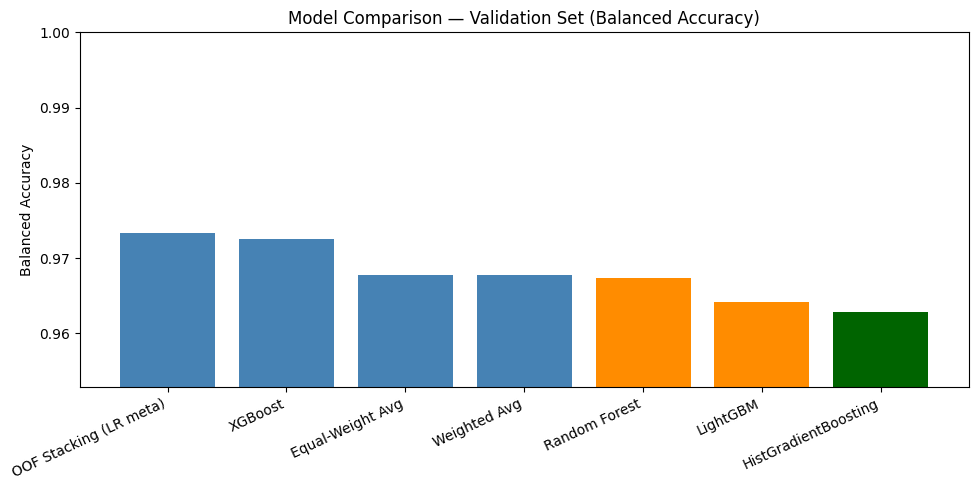

In [33]:
# Stacked model validation evaluation (using models retrained on full data)
val_hgbm_f  = hgbm_final.predict_proba(X_val)
val_lgbm_f  = lgbm_final.predict_proba(X_val)
val_rf_f    = rf_final.predict_proba(X_val)
val_xgb_f   = xgb_final.predict_proba(X_val)
X_meta_val  = np.hstack([val_hgbm_f, val_lgbm_f, val_rf_f, val_xgb_f])
stacked_val = meta_model.predict(X_meta_val)
ba_stacked  = balanced_accuracy_score(y_val, stacked_val)

# Build comparison table
results = pd.DataFrame({
    'Model': ['HistGradientBoosting', 'LightGBM', 'Random Forest', 'XGBoost',
               'Equal-Weight Avg', 'Weighted Avg', 'OOF Stacking (LR meta)'],
    'Balanced Accuracy': [
        hgbm_ba, lgbm_ba, rf_ba, xgb_ba,
        ba_equal, ba_weighted, ba_stacked
    ]
}).sort_values('Balanced Accuracy', ascending=False).reset_index(drop=True)

results['Balanced Accuracy'] = results['Balanced Accuracy'].round(4)
print(results.to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 5))
colors = ['steelblue'] * 4 + ['darkorange'] * 2 + ['darkgreen']
plt.bar(results['Model'], results['Balanced Accuracy'], color=colors)
plt.xticks(rotation=25, ha='right')
plt.ylabel('Balanced Accuracy')
plt.title('Model Comparison — Validation Set (Balanced Accuracy)')
plt.ylim(results['Balanced Accuracy'].min() - 0.01, 1.0)
plt.tight_layout()
plt.show()

In [34]:
# Pick the best ensemble method for submission
best_ba    = results['Balanced Accuracy'].max()
best_model = results.loc[results['Balanced Accuracy'].idxmax(), 'Model']
print(f'Best model: {best_model}  |  Balanced Accuracy: {best_ba}')

Best model: OOF Stacking (LR meta)  |  Balanced Accuracy: 0.9733


## 13. Final Submission

Generate predictions using the best-performing ensemble method.

In [35]:
# Use stacked predictions as default; swap to avg if stacking underperforms
final_preds = stacked_preds  # change to avg_pred_weighted if preferred

submission = pd.DataFrame({
    'id': test_df['id'],
    'Irrigation_Need': le.inverse_transform(final_preds)
})

print('Submission shape:', submission.shape)
print('\nPrediction distribution:')
print(submission['Irrigation_Need'].value_counts())

submission.head(20)

Submission shape: (270000, 2)

Prediction distribution:
Irrigation_Need
Low       159759
Medium    101378
High        8863
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low


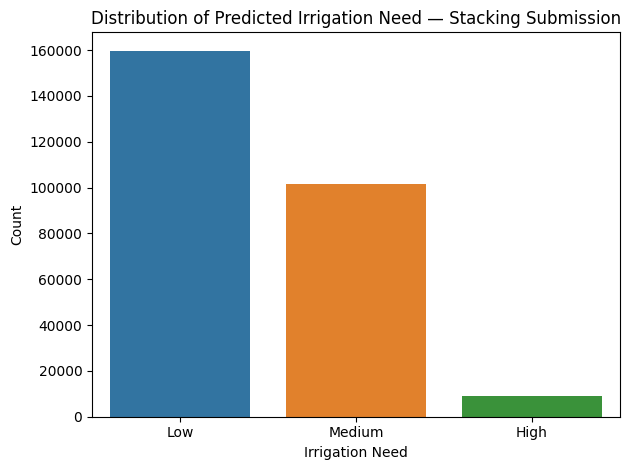

In [38]:
# Visualize submission class distribution
sns.countplot(x='Irrigation_Need', data=submission,
              order=['Low', 'Medium', 'High'],
              hue='Irrigation_Need', legend=False)
plt.title('Distribution of Predicted Irrigation Need — Stacking Submission')
plt.xlabel('Irrigation Need')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [37]:
submission.to_csv('Stacking_HW4_submission.csv', index=False)
print('Saved: Stacking_HW4_submission.csv')

Saved: Stacking_HW4_submission.csv
